In [2]:
from chronos import ChronosPipeline

/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/2438504353.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/2438504353.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].mean().reset_index()



=== CHRONOS – OFF‑shore TEST METRICS ===
Monthly  MSE=430,635,273,628.76  RMSE=656,228.07  MAE=560,518.59  R²=-1.1856  MAPE=32.17%
Weekly   MSE=540,662,352,681.95  RMSE=735,297.46  MAE=597,010.64  R²=-0.0764  MAPE=39.73%


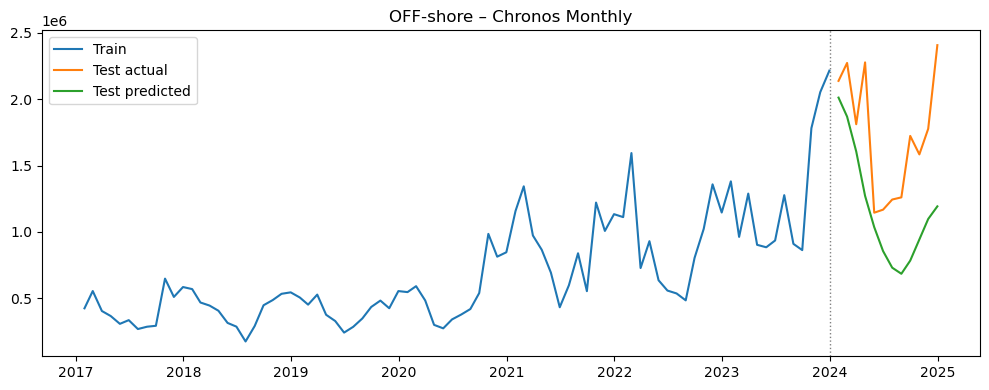

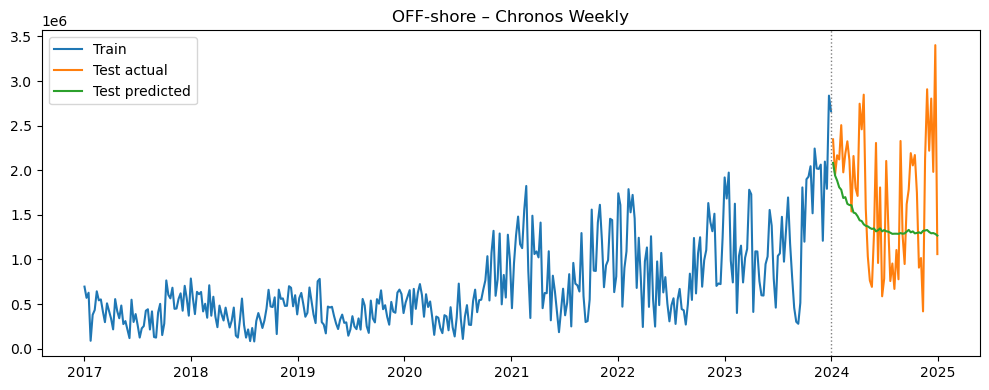

In [ ]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "data/final_offshore_data_2017_2025.csv"
SITE      = "OFF‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].mean().reset_index()
df_W = df.resample("W")["y"].mean().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/1254632510.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/1254632510.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].mean().reset_index()



=== CHRONOS – ON‑shore TEST METRICS ===
Monthly  MSE=231,588,855,683.86  RMSE=481,236.80  MAE=394,316.94  R²=-0.0011  MAPE=19.63%
Weekly   MSE=561,395,200,996.73  RMSE=749,263.11  MAE=611,147.56  R²=0.0605  MAPE=39.25%


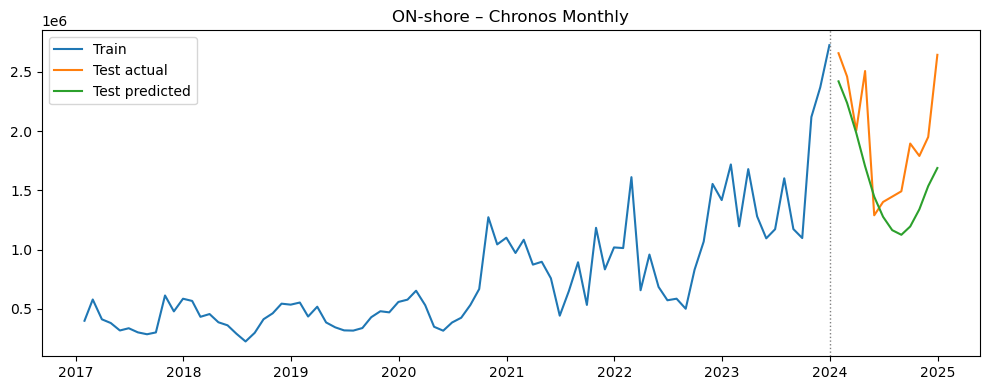

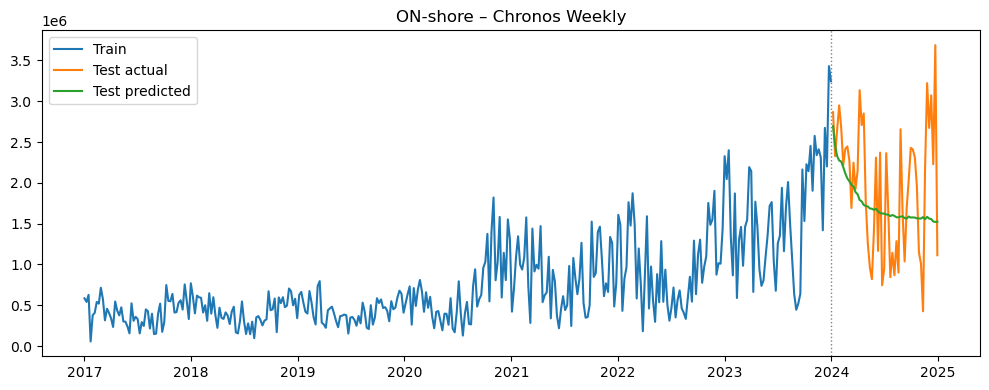

In [ ]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].mean().reset_index()
df_W = df.resample("W")["y"].mean().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy import signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from sktime.forecasting.compose import EnsembleForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from matplotlib.dates import DateFormatter

np.random.seed(42)

In [6]:
# Load the data
db_offshore = pd.read_csv('data/final_offshore_data_2017_2025.csv')
db_onshore = pd.read_csv('data/final_onshore_data_2017_2025.csv')

In [7]:
# Write the function to engineer datetime features
def transform_datetime_features(df, correct_days_column='correct_days', start_date='2017-01-01'):

    df = df.copy()
    
    # Split into 'date' and 'hour'
    df[['date', 'hour']] = df[correct_days_column].str.rsplit('-', n=1, expand=True)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='h')
    
    # Extract month
    df['month'] = df['datetime'].dt.to_period('M').astype(str)
    
    # Calculate week number
    start_date = pd.Timestamp(start_date)
    df['week_number'] = ((df['datetime'] - start_date).dt.days // 7) + 1
    
    return df

# Apply the function to both datasets

db_offshore = transform_datetime_features(db_offshore)
db_onshore = transform_datetime_features(db_onshore)

# Drop datetime 2025-01-01 and set datetime as index
db_offshore = db_offshore[db_offshore['datetime'] != '2025-01-01']
db_onshore = db_onshore[db_onshore['datetime'] != '2025-01-01']

db_offshore.set_index('datetime', inplace=True)
db_onshore.set_index('datetime', inplace=True)

# ##### Offshore data
# Convert hourly data to monthly data
db_off_monthly = db_offshore.groupby('month').mean(numeric_only=True)

train_db_m_off = db_off_monthly[db_off_monthly.index <= '2024-06']
test_db_m_off = db_off_monthly[db_off_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_off_weekly = db_offshore.groupby('week_number').mean(numeric_only=True)

train_db_w_off = db_off_weekly[db_off_weekly.index <= 406]
test_db_w_off = db_off_weekly[db_off_weekly.index > 406]

# Convert hourly data to daily data
db_offshore['date'] = pd.to_datetime(db_offshore['date'], format='%Y-%m-%d')
db_off_daily = db_offshore.groupby('date').mean(numeric_only=True)
db_off_daily.index = pd.to_datetime(db_off_daily.index)

train_db_d_off = db_off_daily[db_off_daily.index <= '2024-11-01']
test_db_d_off = db_off_daily[db_off_daily.index > '2024-11-01']

# Set hourly data
db_off_hourly = db_offshore

# Split into train and test set
train_db_h_off = db_off_hourly[db_off_hourly['date'] <= '2024-12-22']
test_db_h_off = db_off_hourly[db_off_hourly['date'] > '2024-12-22']

# ##### Onshore data

# Convert hourly data to monthly data
db_on_monthly = db_onshore.groupby('month').mean(numeric_only=True)

train_db_m_on = db_on_monthly[db_on_monthly.index <= '2024-06']
test_db_m_on = db_on_monthly[db_on_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_on_weekly = db_onshore.groupby('week_number').mean(numeric_only=True)

train_db_w_on = db_on_weekly[db_on_weekly.index <= 406]
test_db_w_on = db_on_weekly[db_on_weekly.index > 406]

# Convert hourly data to daily data
db_onshore['date'] = pd.to_datetime(db_onshore['date'], format='%Y-%m-%d')
db_on_daily = db_onshore.groupby('date').mean(numeric_only=True)
db_on_daily.index = pd.to_datetime(db_on_daily.index)

train_db_d_on = db_on_daily[db_on_daily.index <= '2024-11-01']
test_db_d_on = db_on_daily[db_on_daily.index > '2024-11-01']

# Set hourly data
db_on_hourly = db_onshore

# Split into train and test set
train_db_h_on = db_on_hourly[db_on_hourly['date'] <= '2024-12-22']
test_db_h_on = db_on_hourly[db_on_hourly['date'] > '2024-12-22']

# ### SARIMAX models
# #### Offshore data

def fit_predict_plot_sarimax(train_db, test_db, target_var, exclude_cols=None,
                             order=(3,1,0), seasonal_periods=12):
    if exclude_cols is None:
        exclude_cols = []

    # 1. Prepare exogenous variables
    drop_cols = [col for col in [target_var] + exclude_cols if col in train_db.columns]
    exog_vars = train_db.columns.drop(drop_cols)
    exog_feature_names = exog_vars.tolist()

    scaler = StandardScaler()
    train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
    test_exog_scaled = scaler.transform(test_db[exog_vars])

    # 2. Define seasonal_order based on provided seasonal_periods
    seasonal_order = (1, 1, 1, seasonal_periods)

    # 3. Fit SARIMAX model
    model = SARIMAX(
        train_db[target_var],
        exog=train_exog_scaled,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit = model.fit(disp=True)

    # 4. Get t-statistics of exogenous coefficients
    exog_coeffs = model_fit.params[model_fit.model.exog_names]
    exog_t_stats = (exog_coeffs / model_fit.bse[model_fit.model.exog_names]).sort_values(ascending=False)

    # 5. Make predictions
    predictions = model_fit.predict(
        start=len(train_db[target_var]),
        end=len(train_db[target_var]) + len(test_db[target_var]) - 1,
        exog=test_exog_scaled,
        dynamic=False
    )

    return model_fit, predictions, exog_t_stats

# ##### Monthly data

model_fit_m_off, predictions_m_off, t_stats_m_off = fit_predict_plot_sarimax(
train_db=train_db_m_off,
test_db=test_db_m_off,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_off[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_off[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_off['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_off = model_fit.predict(
start=len(train_db_w_off['volume']),
end=len(train_db_w_off['volume']) + len(test_db_w_off['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# Filter 2024 data
#train_subset = train_db_w_off[train_db_w_off.index >= 300]
#test_subset = test_db_w_off[test_db_w_off.index >= 300]
##pred_subset = predictions[predictions.index >= 300]


# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_off[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_off[exog_vars])

# Alternative approach:
stl = STL(train_db_d_off['volume'], period=365)
result = stl.fit()
train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_off['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_off = model_fit.predict(
start=len(train_db_d_off['volume']),
end=len(train_db_d_off['volume']) + len(test_db_d_off['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
# train_subset = train_db_d_off[train_db_d_off.index >= "2024-01-01"]
# test_subset = test_db_d_off[test_db_d_off.index >= "2024-01-01"]
# pred_subset = predictions[predictions.index >= "2024-01-01"]

# #### Onshore data

# ##### Monthly data

model_fit_m_on, predictions_m_on, t_stats_m_on = fit_predict_plot_sarimax(
train_db=train_db_m_on,
test_db=test_db_m_on,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_on[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_on[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_on['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_on = model_fit.predict(
start=len(train_db_w_on['volume']),
end=len(train_db_w_on['volume']) + len(test_db_w_on['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_on[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_on[exog_vars])

# Alternative approach:
stl = STL(train_db_d_on['volume'], period=365)
result = stl.fit()
train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_on['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_on = model_fit.predict(
start=len(train_db_d_on['volume']),
end=len(train_db_d_on['volume']) + len(test_db_d_on['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
# train_subset = train_db_d_on[train_db_d_on.index >= "2024-01-01"]
# test_subset = test_db_d_on[test_db_d_on.index >= "2024-01-01"]
# pred_subset = predictions[predictions.index >= "2024-01-01"]

/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.78706D+07    |proj g|=  7.88053D+07

At iterate    1    f=  1.14684D+07    |proj g|=  4.89752D+07

At iterate    2    f=  4.99713D+06    |proj g|=  3.93105D+07

At iterate    3    f=  3.34500D+05    |proj g|=  1.24637D+07

At iterate    4    f=  3.01918D+04    |proj g|=  2.55078D+06

At iterate    5    f=  1.99028D+03    |proj g|=  8.51312D+05

At iterate    6    f=  1.59719D+01    |proj g|=  3.31710D+04

At iterate    7    f=  1.18003D+01    |proj g|=  5.53041D+03

At iterate    8    f=  1.16980D+01    |proj g|=  1.30602D+03

At iterate    9    f=  1.16974D+01    |proj g|=  2.13437D+03



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



At iterate   10    f=  1.16952D+01    |proj g|=  1.56510D+03



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.


...

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.21208D+01    |proj g|=  6.82542D-02

At iterate    1    f=  1.21120D+01    |proj g|=  3.84685D-02

At iterate    2    f=  1.21074D+01    |proj g|=  3.87482D-02

At iterate    3    f=  1.21008D+01    |proj g|=  2.69341D-02

At iterate    4    f=  1.21003D+01    |proj g|=  1.88450D-02

At iterate    5    f=  1.20998D+01    |proj g|=  2.53240D-03

At iterate    6    f=  1.20998D+01    |proj g|=  3.71820D-04

At iterate    7    f=  1.20998D+01    |proj g|=  1.49549D-04

At iterate    8    f=  1.20998D+01    |proj g|=  1.39547D-04

At iterate    9    f=  1.20998D+01    |proj g|=  1.51500D-05

At iterate   10    f=  1.20998D+01    |proj g|=  8.46788D-07

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/1818585072.py:279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal
/opt/anaconda3/envs

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.41143D+01    |proj g|=  7.25353D-02


 This problem is unconstrained.



At iterate    1    f=  1.40969D+01    |proj g|=  1.17539D-01

At iterate    2    f=  1.40748D+01    |proj g|=  7.99484D-02

At iterate    3    f=  1.40694D+01    |proj g|=  3.84903D-02

At iterate    4    f=  1.40664D+01    |proj g|=  1.41217D-02

At iterate    5    f=  1.40655D+01    |proj g|=  6.47828D-03

At iterate    6    f=  1.40650D+01    |proj g|=  5.56034D-03

At iterate    7    f=  1.40645D+01    |proj g|=  1.55139D-02

At iterate    8    f=  1.40637D+01    |proj g|=  1.21960D-03

At iterate    9    f=  1.40636D+01    |proj g|=  1.06709D-03

At iterate   10    f=  1.40636D+01    |proj g|=  7.34839D-04

At iterate   11    f=  1.40636D+01    |proj g|=  1.37290D-03

At iterate   12    f=  1.40635D+01    |proj g|=  1.14488D-04

At iterate   13    f=  1.40635D+01    |proj g|=  1.24736D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates

/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/1142322422.py:137: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  + pd.to_timedelta(df["hour"].astype(int) - 1, unit="H"))


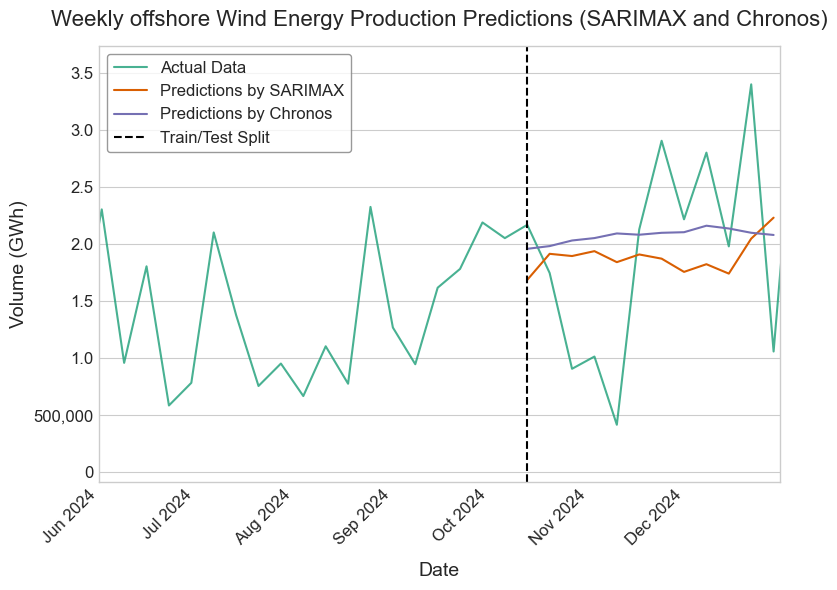

/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_56426/1142322422.py:137: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  + pd.to_timedelta(df["hour"].astype(int) - 1, unit="H"))


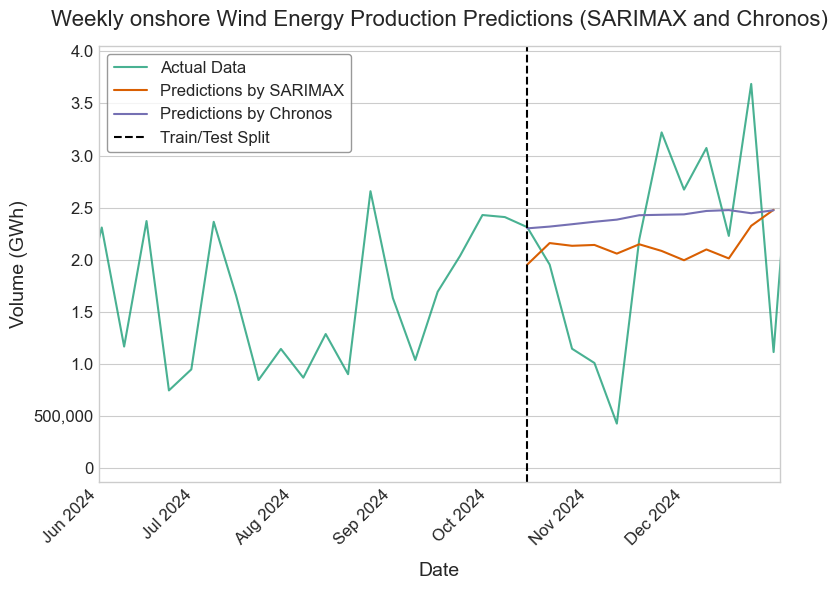

✅ Weekly charts saved to: /Users/polina/Watts-next/plots


In [15]:
# ================================================================
# 0. Imports & robust “seaborn-whitegrid” style
# ================================================================
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.statespace.sarimax import SARIMAX
from chronos import ChronosPipeline
from pathlib import Path

# White-grid look, independent of Matplotlib version
try:
    plt.style.use("seaborn-whitegrid")          # Matplotlib ≤3.7
except OSError:
    try:
        plt.style.use("seaborn-v0_8-whitegrid") # Matplotlib ≥3.8
    except OSError:                             # fallback → seaborn
        import seaborn as sns
        sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["savefig.dpi"] = 300


# ================================================================
# 1. Helper utilities
# ================================================================
def millions(x, _):
    """Formatter: 2 000 000 → 2.0 (for Y-axis)."""
    return f"{x/1_000_000:.1f}" if abs(x) >= 1_000_000 else f"{x:,.0f}"

def clip(series, start, end):
    """Trim *series* to the interval [start, end]."""
    return series.loc[(series.index >= start) & (series.index <= end)]

def sarimax_weekly(train: pd.Series, steps: int) -> pd.Series:
    """Basic SARIMAX(3,1,1)(1,1,1,52) weekly forecast."""
    model = SARIMAX(train,
                    order=(3, 1, 1),
                    seasonal_order=(1, 1, 1, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    res = model.fit(disp=False)
    fc = res.get_prediction(len(train), len(train)+steps-1).predicted_mean
    return fc

def chronos_fc(series, horizon, pl: ChronosPipeline):
    """Run Chronos median forecast (`q=0.5`) and return NumPy 1-D array."""
    ctx = torch.tensor(series, dtype=torch.float32)
    _, q_map = pl.predict_quantiles(ctx, horizon, [0.5],
                                    limit_prediction_length=False)
    preds = q_map[0]
    return (
        preds.detach().cpu().numpy()
        if preds.ndim == 1
        else preds.mean(dim=0).detach().cpu().numpy()
    )

def make_plot(actual, sarimax_pred, chronos_pred,
              split_date, title, save_path,
              xlim=("2024-06-01", "2024-12-31")):
    """Render the weekly chart in the house style."""
    start, end = map(pd.to_datetime, xlim)
    sarimax_pred = clip(sarimax_pred, start, end)
    chronos_pred = clip(chronos_pred, start, end)

    ymax = 1.1 * max(actual.loc[start:end].max(),
                     sarimax_pred.max(), chronos_pred.max())

    fig, ax = plt.subplots()
    ax.set_facecolor("white")

    # Actual history
    ax.plot(actual.index, actual.values,
            label="Actual Data", color="#1b9e77", alpha=0.8)

    # Forecast lines (12 weeks)
    ax.plot(sarimax_pred.index,  sarimax_pred.values,
            label="Predictions by SARIMAX", color="#d95f02")
    ax.plot(chronos_pred.index, chronos_pred.values,
            label="Predictions by Chronos",  color="#7570b3")

    # Train / test split
    ax.axvline(pd.to_datetime(split_date), color="k", ls="--",
               label="Train/Test Split")

    # Cosmetics
    ax.set_title(title, pad=14, fontsize=16)
    ax.set_xlabel("Date", labelpad=10, fontsize=14)
    ax.set_ylabel("Volume (GWh)", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="x")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=45)
    ax.set_xlim(start, end)

    ax.set_ylim(top=ymax)
    ax.yaxis.set_major_formatter(FuncFormatter(millions))

    ax.legend(loc="best", fontsize=12,
              frameon=True, facecolor="white",
              edgecolor="grey", fancybox=True, framealpha=0.8)

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()


# ================================================================
# 2. Data paths & output directory
# ================================================================
DATA = {
    "OFF": "/Users/polina/Watts-next/data/final_offshore_data_2017_2025.csv",
    "ON":  "/Users/polina/Watts-next/data/final_onshore_data_2017_2025.csv",
}
OUT = Path("plots"); OUT.mkdir(exist_ok=True)

# Load Chronos once
chronos_pipe = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32
)


# ================================================================
# 3. Main loop – build & plot for each site
# ================================================================
for tag, csv_path in DATA.items():
    # ----- Load & preprocess ------------------------------------
    df = pd.read_csv(csv_path)
    df[["date", "hour"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
    df["ds"] = (pd.to_datetime(df["date"])
                + pd.to_timedelta(df["hour"].astype(int) - 1, unit="H"))
    df["y"] = df["volume"]
    df = df.sort_values("ds").set_index("ds")

    # Weekly mean
    weekly = df["y"].resample("W").mean()

    # ----- Define 12-week test window (Oct–Dec 2024) ------------
    weekly_2024 = weekly["2024"]
    test_weeks  = weekly_2024.tail(12)               # final 12 weeks
    train_weeks = weekly.loc[: test_weeks.index.min() - pd.Timedelta(days=7)]

    # ----- Forecasts --------------------------------------------
    sarimax_pred = sarimax_weekly(train_weeks, len(test_weeks))
    chronos_pred = pd.Series(
        chronos_fc(train_weeks.values, len(test_weeks), chronos_pipe),
        index=test_weeks.index
    )

    # ----- Plot --------------------------------------------------
    make_plot(
        actual=weekly,
        sarimax_pred=sarimax_pred,
        chronos_pred=chronos_pred,
        split_date=test_weeks.index.min(),      # vertical line ≈ early Oct
        title=(f"Weekly {tag.lower()}shore Wind Energy Production "
               f"Predictions (SARIMAX and Chronos)"),
        save_path=OUT / f"{tag.lower()}_weekly_chronos.png",
        xlim=("2024-06-01", "2024-12-31")
    )

print("✅ Weekly charts saved to:", OUT.resolve())
